In [4]:
import numpy as np
import matplotlib.pyplot as plt

layer_rdm_path = "./CLIPViT_visual_encoder_24layers_RDM.npy"
layer_rdm = np.load(layer_rdm_path)
print(layer_rdm.shape)

(24, 1854, 1854)


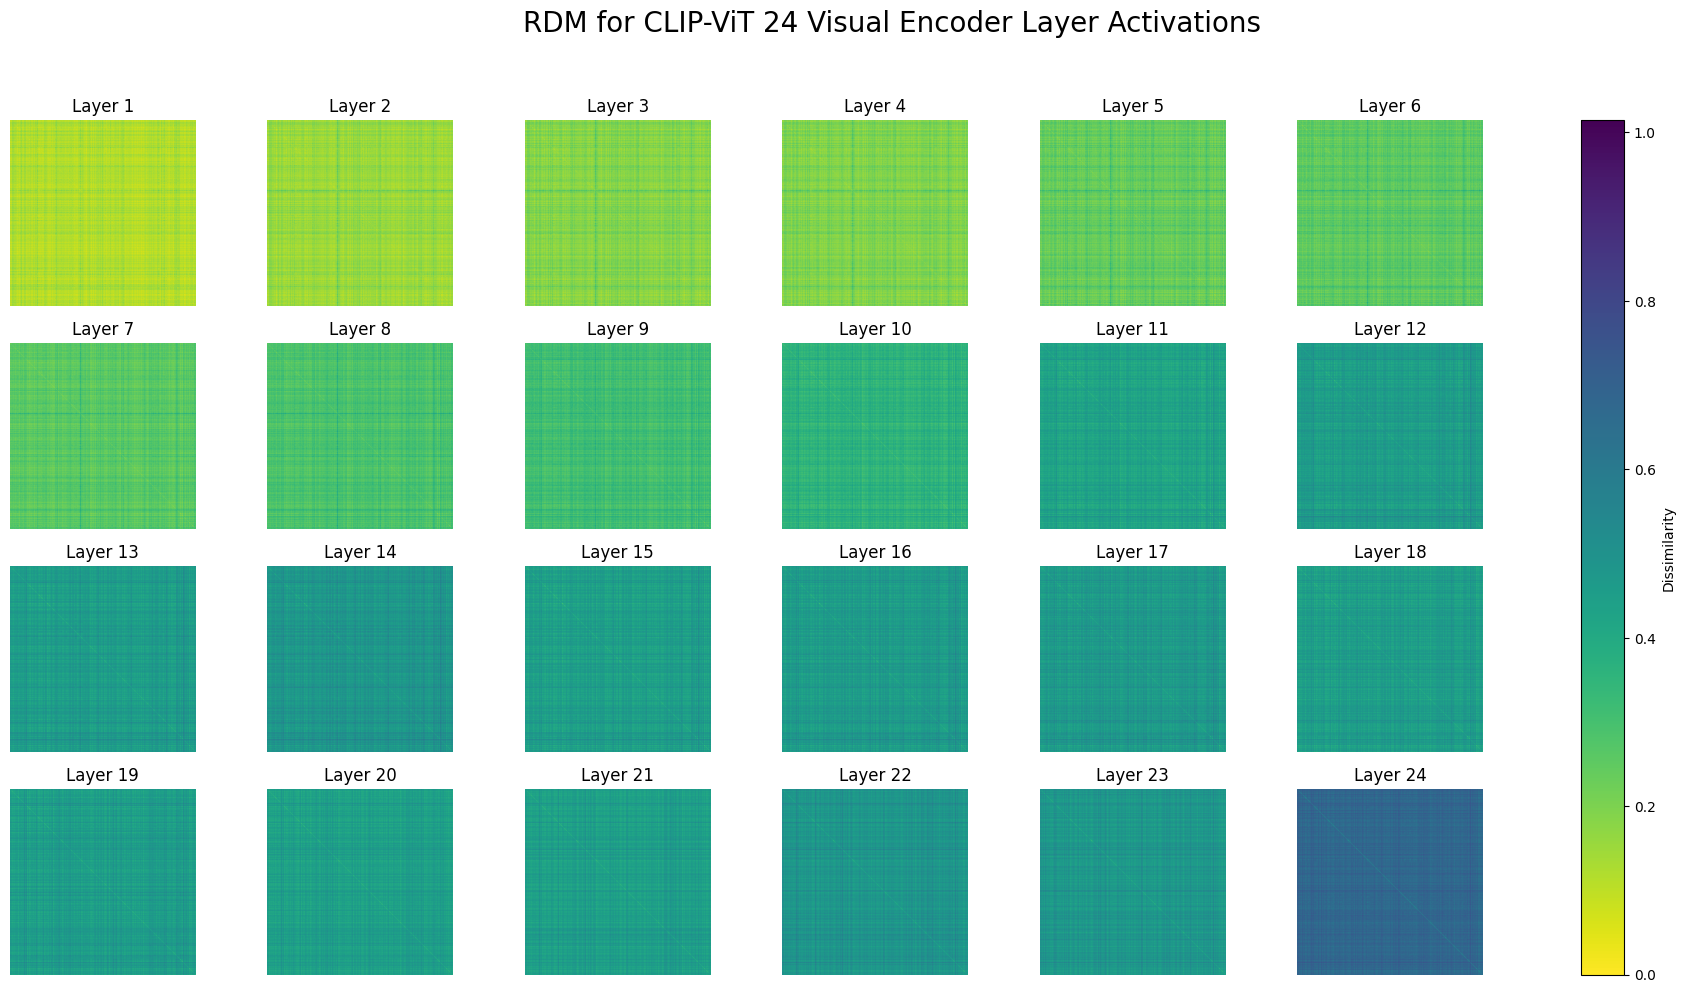

In [5]:
import matplotlib.pyplot as plt

# Create the subplots
fig, axes = plt.subplots(4, 6, figsize=(20, 10))
fig.suptitle("RDM for CLIP-ViT 24 Visual Encoder Layer Activations", fontsize=20)

# Plot each RDM and add them to the subplots
for i in range(24):
    ax = axes[i // 6, i % 6]
    im = ax.imshow(layer_rdm[i], cmap='viridis_r')
    ax.set_title(f'Layer {i+1}')
    ax.axis('off')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Add a color bar
cbar = fig.colorbar(im, ax=axes, orientation='vertical')
cbar.set_label('Dissimilarity')

# Show the plot
plt.show()


In [1]:
from scipy.stats import spearmanr
import numpy as np

# Load the .mat file
meg_rdm = "../Data/Cichy/Cichy_MEG_RDM_Rescaled.npy"
print("loading Things MEG RDM")
all_rdms = np.load(meg_rdm, allow_pickle=True)
print(all_rdms.shape)

loading Things MEG RDM
(15, 1101, 118, 118)


In [2]:
meg_mean_rdm = np.mean(all_rdms, axis=0)
meg_mean_rdm.shape

(1101, 118, 118)

In [10]:
from tqdm import tqdm

def calculate_model_correlation(group_mean_rdms, layer_rdm):
    layer_correlations = np.zeros((layer_rdm.shape[0], group_mean_rdms.shape[0]))
    for time_point in tqdm(range(group_mean_rdms.shape[0]), desc="Processing Timepoints..."):
        indices = np.triu_indices_from(group_mean_rdms[time_point], k=1)
        group_mean_rdm_flat = group_mean_rdms[time_point][indices]
        for layer in range(layer_rdm.shape[0]):
            indices = np.triu_indices_from(layer_rdm[layer], k=1)
            layer_rdm_flat = layer_rdm[layer][indices]
            corr, _ = spearmanr(layer_rdm_flat, group_mean_rdm_flat, nan_policy='omit')
            layer_correlations[layer, time_point] = corr
    return layer_correlations

layer_correlation = calculate_model_correlation(meg_mean_rdm, layer_rdm)
print(layer_correlation.shape)

Processing Timepoints...: 100%|██████████| 1101/1101 [00:35<00:00, 31.34it/s]

(24, 1101)


In [11]:
np.save("CLIPViT_visual_encoder_24layers_neural_correlation_1101timepoints_cichy.npy", layer_correlation)

In [12]:
path = "./CLIPViT_visual_encoder_24layers_neural_correlation_1101timepoints_cichy.npy"
layer_correlation = np.load(path)
print(layer_correlation.shape)

(24, 1101)


C:\Users\BrainInspired\AppData\Local\Temp\ipykernel_3736\2658373464.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('viridis_r', layer_correlation.shape[0])


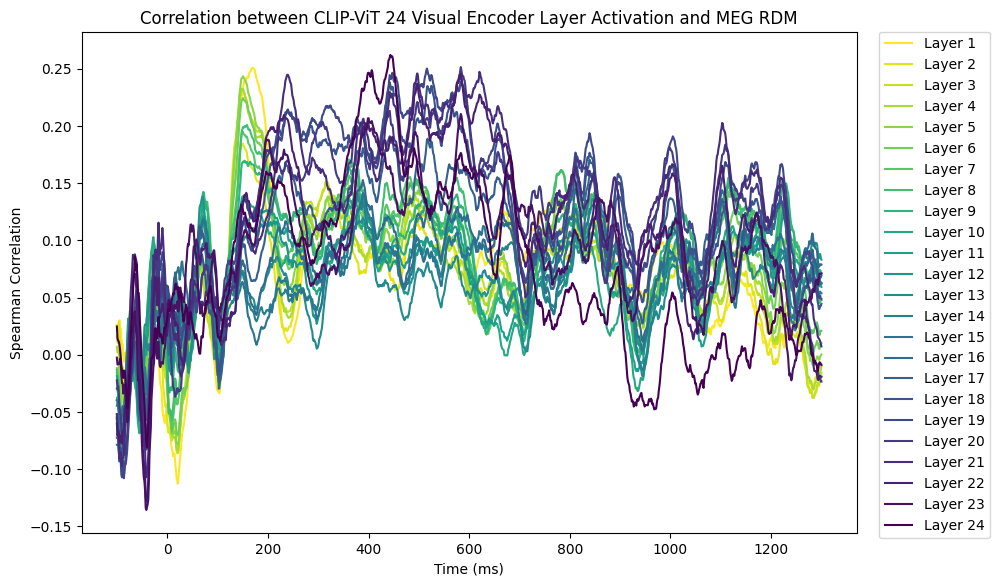

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Assuming `layer_correlation` is your data
time_points = np.linspace(-100, 1300, layer_correlation.shape[1])

# Use the viridis colormap
colormap = cm.get_cmap('viridis_r', layer_correlation.shape[0])

fig, ax = plt.subplots(figsize=(10, 6.5))
for layer in range(layer_correlation.shape[0]):
    ax.plot(time_points, layer_correlation[layer], label=f'Layer {layer+1}', color=colormap(layer))
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spearman Correlation')
ax.set_title('Correlation between CLIP-ViT 24 Visual Encoder Layer Activation and MEG RDM')
ax.legend(bbox_to_anchor=(1.02, 1.015), loc='upper left')
plt.show();


In [14]:
meg_mean_rdm.shape
meg_mean_rdm = np.nan_to_num(meg_mean_rdm)
meg_mean_rdm[0]

array([[0.        , 0.51966667, 0.51233333, ..., 0.50966667, 0.52066667,
        0.456     ],
       [0.51966667, 0.        , 0.51633333, ..., 0.46966667, 0.47233333,
        0.50466667],
       [0.51233333, 0.51633333, 0.        , ..., 0.50033333, 0.521     ,
        0.535     ],
       ...,
       [0.50966667, 0.46966667, 0.50033333, ..., 0.        , 0.47533333,
        0.48266667],
       [0.52066667, 0.47233333, 0.521     , ..., 0.47533333, 0.        ,
        0.484     ],
       [0.456     , 0.50466667, 0.535     , ..., 0.48266667, 0.484     ,
        0.        ]])

In [16]:
layer_activation = np.load("CLIPViT_visual_encoder_24layers_activations_cichy.npy")
layer_activation = layer_activation.reshape(layer_activation.shape[0], layer_activation.shape[1], -1)
layer_activation.shape

(24, 118, 1024)

Move to "encoder_layer_weight_ridge_regression.py"

In [27]:
path = "CLIPViT_visual_encoder_24layers_optimal_weights.npy"
optimal_weights = np.load(path)
optimal_weights.shape

(281, 24)

In [31]:
def ms_to_timepoints(ms, ms_start=-100, ms_step=5):
    timepoint = (ms - ms_start) // ms_step + 1
    return timepoint

test_timepoints = ms_to_timepoints(500)
optimal_weights[123]

array([0.01239979, 0.02764027, 0.08306343, 0.07568668, 0.07797333,
       0.00839907, 0.04548088, 0.05701817, 0.0288665 , 0.03946035,
       0.04273096, 0.03778789, 0.03724246, 0.03803937, 0.03568942,
       0.04286429, 0.03031846, 0.04932455, 0.03567594, 0.03563278,
       0.04288485, 0.03694174, 0.03748203, 0.04139679])